In [14]:
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
from imblearn.over_sampling import RandomOverSampler
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.utils.validation import check_is_fitted
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [15]:
df = pd.read_csv("framingham (1).csv")

In [16]:
df.head(10)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,0,43,2.0,0,0.0,0.0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0
6,0,63,1.0,0,0.0,0.0,0,0,0,205.0,138.0,71.0,33.11,60.0,85.0,1
7,0,45,2.0,1,20.0,0.0,0,0,0,313.0,100.0,71.0,21.68,79.0,78.0,0
8,1,52,1.0,0,0.0,0.0,0,1,0,260.0,141.5,89.0,26.36,76.0,79.0,0
9,1,43,1.0,1,30.0,0.0,0,1,0,225.0,162.0,107.0,23.61,93.0,88.0,0


In [17]:
df.shape

(4240, 16)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [19]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [20]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [21]:
x = df.drop(columns= 'TenYearCHD')
y = df.TenYearCHD

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42, stratify=y)

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2,random_state=42,stratify=y_train)

In [46]:
model = make_pipeline(
    SimpleImputer(strategy='mean'),
    DecisionTreeClassifier(
        max_depth=25,
        random_state=42
    )
)
model.fit(x_train,y_train)

,steps,"[('simpleimputer', ...), ('decisiontreeclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,criterion,'gini'


In [47]:
model.score(x_train, y_train)

1.0

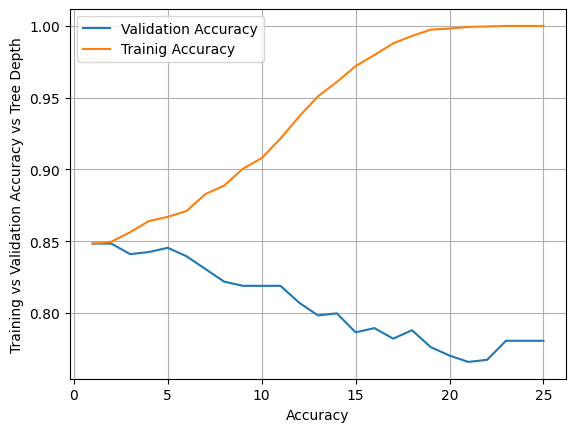

In [49]:
val_acc = []
train_acc = []

for d in range(1,26):
    model = make_pipeline(SimpleImputer(), DecisionTreeClassifier(max_depth=d, random_state=42))
    model.fit(x_train, y_train)
    val_acc.append(model.score(x_val, y_val))
    train_acc.append(model.score(x_train, y_train))
    
plt.plot(range(1,26), val_acc, label = 'Validation Accuracy')
plt.plot(range(1,26), train_acc, label='Trainig Accuracy')
plt.xlabel("Accuracy")
plt.ylabel("Training vs Validation Accuracy vs Tree Depth")
plt.grid()
plt.legend()

In [61]:
over_sampler = RandomOverSampler(random_state=42)
x_train_over, y_train_over = over_sampler.fit_resample(x_train,y_train)

print("original train shape:", x_train.shape)
print("oversamples train shape:", x_train_over.shape)



original train shape: (2713, 15)
oversamples train shape: (4602, 15)


In [62]:
model2 = make_pipeline(SimpleImputer(), RandomForestClassifier())
print(model2)

Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('randomforestclassifier', RandomForestClassifier())])


In [63]:
cv_acc_scores = cross_val_score(model2, x_train_over, y_train_over, cv=5, n_jobs=-1)

In [64]:
print(cv_acc_scores)
print("mean CV Accuracy:", cv_acc_scores)

[0.97176982 0.97394137 0.9673913  0.97934783 0.98478261]
mean CV Accuracy: [0.97176982 0.97394137 0.9673913  0.97934783 0.98478261]


In [65]:
params = {
    "simpleimputer__strategy": ["mean", "median"],
    "randomforestclassifier__n_estimators": [10, 100],
    "randomforestclassifier__max_depth": [2, 10, 30]
}

In [66]:
model_main = GridSearchCV(
    model2,
    param_grid=params,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring="roc_auc"
)

In [74]:
import joblib

joblib.dump(best_model, "chd_model.pkl")

['chd_model.pkl']

In [67]:
model_main.fit(x_train_over, y_train_over)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,Pipeline(step...lassifier())])
,param_grid,"{'randomforestclassifier__max_depth': [2, 10, ...], 'randomforestclassifier__n_estimators': [10, 100], 'simpleimputer__strategy': ['mean', 'median']}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,missing_values,nan


In [68]:
cv_results = pd.DataFrame(model_main.cv_results_)
cv_results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_randomforestclassifier__max_depth,param_randomforestclassifier__n_estimators,param_simpleimputer__strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.045663,0.003258,0.008918,0.001798,2,10,mean,"{'randomforestclassifier__max_depth': 2, 'rand...",0.723852,0.732670,0.723516,0.723450,0.707616,0.722221,0.008104,11
1,0.043431,0.002377,0.008821,0.001853,2,10,median,"{'randomforestclassifier__max_depth': 2, 'rand...",0.743761,0.710374,0.725619,0.727472,0.699386,0.721322,0.015237,12
2,0.359301,0.013822,0.018252,0.003053,2,100,mean,"{'randomforestclassifier__max_depth': 2, 'rand...",0.753395,0.725439,0.736753,0.740019,0.707847,0.732691,0.015288,9
3,0.303509,0.005367,0.016233,0.001287,2,100,median,"{'randomforestclassifier__max_depth': 2, 'rand...",0.753096,0.718106,0.741675,0.740832,0.701271,0.730996,0.018702,10
4,0.070293,0.006185,0.007924,0.000440,10,10,mean,"{'randomforestclassifier__max_depth': 10, 'ran...",0.948161,0.954881,0.935373,0.957528,0.962625,0.951714,0.009408,8
5,0.073059,0.003045,0.008385,0.000636,10,10,median,"{'randomforestclassifier__max_depth': 10, 'ran...",0.948746,0.964944,0.946843,0.951923,0.960336,0.954558,0.006950,7
6,0.587489,0.020637,0.026501,0.002863,10,100,mean,"{'randomforestclassifier__max_depth': 10, 'ran...",0.965670,0.971621,0.968497,0.982708,0.973757,0.972451,0.005817,5
7,0.572946,0.005171,0.026356,0.001818,10,100,median,"{'randomforestclassifier__max_depth': 10, 'ran...",0.965835,0.966802,0.966862,0.982131,0.970137,0.970353,0.006066,6
8,0.076795,0.001820,0.008509,0.000592,30,10,mean,"{'randomforestclassifier__max_depth': 30, 'ran...",0.989524,0.998069,0.999348,0.999542,0.997795,0.996856,0.003729,4
9,0.084556,0.009447,0.008560,0.000711,30,10,median,"{'randomforestclassifier__max_depth': 30, 'ran...",0.989689,0.998441,0.998627,0.998681,0.999643,0.997017,0.003687,3


In [69]:
best_model = model_main.best_estimator_

test_score = best_model.score(x_test, y_test)
print("Test Score:", test_score)

Test Score: 0.8372641509433962


In [ ]:
male = widgets.IntText(description="Male (0/1):")
age = widgets.IntText(description="Age:")
education = widgets.FloatText(description="Education:")
currentSmoker = widgets.IntText(description="Smoker (0/1):")
cigsPerDay = widgets.FloatText(description="Cigs/Day:")
BPMeds = widgets.IntText(description="BP Meds (0/1):")
prevalentStroke = widgets.IntText(description="Stroke (0/1):")
prevalentHyp = widgets.IntText(description="Hypertension (0/1):")
diabetes = widgets.IntText(description="Diabetes (0/1):")
totChol = widgets.FloatText(description="Cholesterol:")
sysBP = widgets.FloatText(description="Sys BP:")
diaBP = widgets.FloatText(description="Dia BP:")
BMI = widgets.FloatText(description="BMI:")
heartRate = widgets.FloatText(description="Heart Rate:")
glucose = widgets.FloatText(description="Glucose:")

predict_btn = widgets.Button(description="Predict CHD Risk")
output = widgets.Output()

In [71]:
def predict_chd(b):
    with output:
        output.clear_output()

        data = pd.DataFrame([{
            "male": male.value,
            "age": age.value,
            "education": education.value,
            "currentSmoker": currentSmoker.value,
            "cigsPerDay": cigsPerDay.value,
            "BPMeds": BPMeds.value,
            "prevalentStroke": prevalentStroke.value,
            "prevalentHyp": prevalentHyp.value,
            "diabetes": diabetes.value,
            "totChol": totChol.value,
            "sysBP": sysBP.value,
            "diaBP": diaBP.value,
            "BMI": BMI.value,
            "heartRate": heartRate.value,
            "glucose": glucose.value
        }])

        pred = best_model.predict(data)[0]

        if pred == 1:
            print("⚠ High Risk of CHD")
        else:
            print("✅ Low Risk of CHD")

In [72]:
predict_btn.on_click(predict_chd)

In [73]:
display(
    male, age, education, currentSmoker, cigsPerDay,
    BPMeds, prevalentStroke, prevalentHyp, diabetes,
    totChol, sysBP, diaBP, BMI, heartRate, glucose,
    predict_btn, output
)

IntText(value=0, description='Male (0/1):')

IntText(value=0, description='Age:')

FloatText(value=0.0, description='Education:')

IntText(value=0, description='Smoker (0/1):')

FloatText(value=0.0, description='Cigs/Day:')

IntText(value=0, description='BP Meds (0/1):')

IntText(value=0, description='Stroke (0/1):')

IntText(value=0, description='Hypertension (0/1):')

IntText(value=0, description='Diabetes (0/1):')

FloatText(value=0.0, description='Cholesterol:')

FloatText(value=0.0, description='Sys BP:')

FloatText(value=0.0, description='Dia BP:')

FloatText(value=0.0, description='BMI:')

FloatText(value=0.0, description='Heart Rate:')

FloatText(value=0.0, description='Glucose:')

Button(description='Predict CHD Risk', style=ButtonStyle())

Output()